# Map-Reduce - Send API
Map-reduce operations are essential for efficient task decomposition and parallel processing. 

## It has two phases:

(1) Map - Break a task into smaller sub-tasks, processing each sub-task in parallel.
(2) Reduce - Aggregate the results across all of the completed, parallelized sub-tasks.

### Map‑Reduce in LangGraph = Break a big task into many small tasks (map) → run them in parallel → merge results (reduce).

### Send API = A special LangGraph feature that lets a node dynamically send work to other nodes at runtime
- Each task runs the same node with different input.
- LangGraph runs all tasks in parallel.

### Steps:
1. Create a state with a list of items.
2. Write a map node that returns Send("process_item", list_of_states).
3. Write a process_item node that handles one item.
4. Write a reduce node that receives all merged results.
5. Build the graph and run it.

### Goal:  Generate a simple graph with map-reduce and send API to capture a best joke
Let's design a system that will do two things:

(1) `Map` - Create a set of jokes about a topic.

(2) `Reduce` - Pick the best joke from the list.

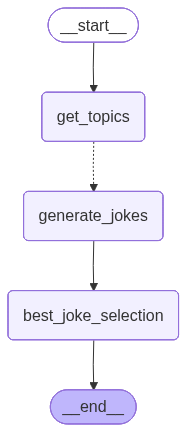

In [16]:
from IPython.display import display , Image
from typing import TypedDict , Optional ,List, Literal , Annotated
from operator import add 
from langgraph.graph import StateGraph, START , END

# create a class 
class Joke_state(TypedDict):
    topics: list[str]
    jokes: Annotated[list[str], add]
    best_joke:str
    


#define node functions
def get_topics(state):
    topics = ['Animals' , 'Birds' , "General"]    
    return {'topics': topics }

# generate jokes for topics
def generate_jokes(state):
    topic = state['topic']
    jokes = {}
    if topic.lower() == 'animals':
        joke = 'Why Lions hate fast food? because they cant catch it.'
        jokes[topic.lower()] = joke
    elif topic.lower() == 'birds':
        joke = "Why penguins dont like talking to strangers in the party? because, they have to break the ice."
        jokes[topic.lower()] = joke
    else:
        joke = "Why don’t scientists trust atoms anymore? Because they make up everything — including the Earth."
        jokes[topic.lower()] = joke
    return  { 'jokes': [jokes]}

# map -reduce
from langgraph.types import Send

def map_get_joke(state):
    topics = state['topics']
    return [Send('generate_jokes' , {'topic': topic}) for topic in topics] # list comprehension

# get best joke

def best_joke_selection(state):
    jokes = state['jokes']
    for joke in jokes:
        if 'birds' in joke:
            return { 'best_joke' : joke }

# build graph

builder = StateGraph(Joke_state)

builder.add_node('get_topics' , get_topics)
builder.add_node('generate_jokes' , generate_jokes)
builder.add_node('best_joke_selection' , best_joke_selection)


# Flow
builder.set_entry_point('get_topics')
builder.add_conditional_edges('get_topics' , map_get_joke, ['generate_jokes'])
builder.add_edge('generate_jokes' , 'best_joke_selection')
builder.add_edge('best_joke_selection', END)

# compile
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
    


    


In [18]:
# stream 
for chunk in graph.stream({}):
    print(chunk)
    print("-"*40)


{'get_topics': {'topics': ['Animals', 'Birds', 'General']}}
----------------------------------------
{'generate_jokes': {'jokes': [{'animals': 'Why Lions hate fast food? because they cant catch it.'}]}}
----------------------------------------
{'generate_jokes': {'jokes': [{'birds': 'Why penguins dont like talking to strangers in the party? because, they have to break the ice.'}]}}
----------------------------------------
{'generate_jokes': {'jokes': [{'general': 'Why don’t scientists trust atoms anymore? Because they make up everything — including the Earth.'}]}}
----------------------------------------
{'best_joke_selection': {'best_joke': {'birds': 'Why penguins dont like talking to strangers in the party? because, they have to break the ice.'}}}
----------------------------------------


{'birds': 'Why penguins dont like talking to strangers in the party? because, they have to break the ice.'}
